# 06 · PCA 결과 비교와 주제 선정

1~5번 노트북의 추가 PCA에서 저장한 요약을 비교합니다. 먼저 해당 노트북을 실행하세요.

**설명 분산 비율은 모델 성능 점수가 아닙니다.** 변수 수, 스케일링 방식, 참조 집합이 다르므로 아래 값은 각 데이터의 압축 정도만 나타냅니다. T²·SPE의 절댓값은 주제 간 비교하지 않습니다. 모든 PCA 결과는 탐색용이며 홀드아웃 F1-score를 측정하지 않았습니다.


,analysis,reference,reference_rows,evaluation_rows,features,rank,PC1_PC2_variance_pct,components_for_95pct,residual_components,residual_model_variance_pct
0,01 사출성형기,라벨 보유 공정값 중복 제거; 전체 파일 투영,1197,73573,23,23,36.881085,17,17,96.296119
1,02 용접기,원본 전체 행; 작업 날짜별 투영,11939,11939,4,4,62.182092,4,3,85.299533
2,03 예지보전 원시,정상 파일 전체 행 학습; 정상·이상 투영,20000,20600,3,3,78.943035,3,2,78.943035
3,03 예지보전 RMS,정상 RMS 창 학습; 정상·이상 RMS 투영,14871,15299,3,3,98.133880,2,2,98.133880
4,04 X-ray 픽셀,고유 이미지 전체; 중심화만 적용; 학습 내 오차,15,15,3672,14,70.688601,8,8,95.723883
5,05 자원 최적화,유효 시각 전체 행; 생산 여부별 비교,6120,6120,9,9,52.926551,7,7,96.332280


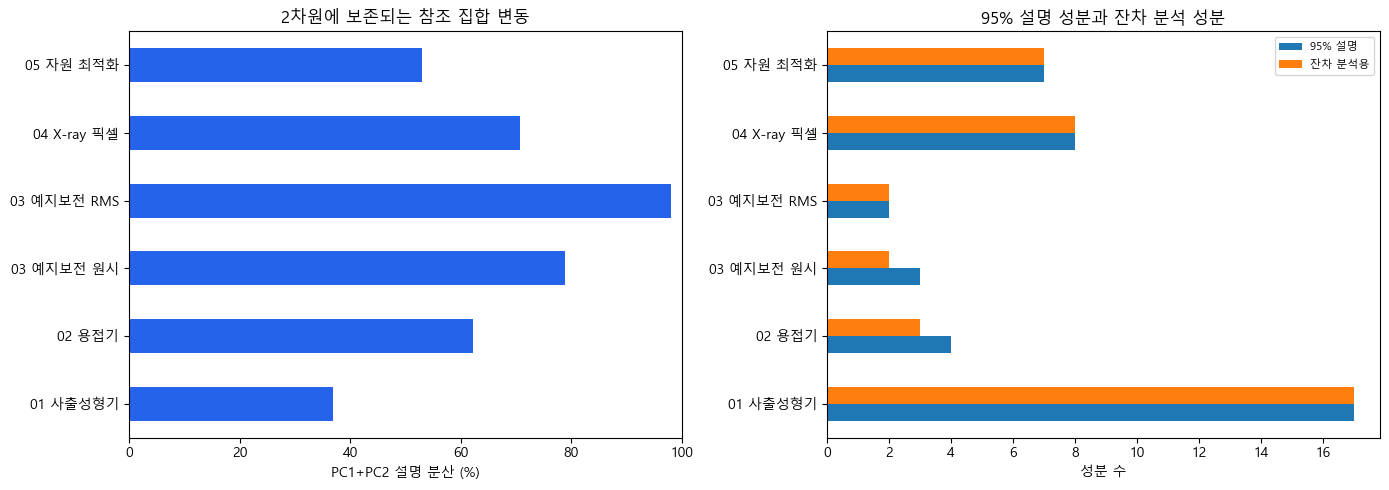

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data').is_dir())
fonts={f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family']=next((f for f in ['Malgun Gothic','AppleGothic','NanumGothic'] if f in fonts),'DejaVu Sans')
plt.rcParams['axes.unicode_minus']=False
paths=[ROOT/'outputs'/'pca'/f'topic{i:02d}.json' for i in range(1,6)]
missing=[str(p) for p in paths if not p.exists()]
assert not missing,f'1~5번 노트북을 먼저 실행하세요: {missing}'
results=pd.DataFrame([row for p in paths for row in json.loads(p.read_text(encoding='utf-8'))])
display(results)
fig,axes=plt.subplots(1,2,figsize=(14,5))
results.plot.barh(x='analysis',y='PC1_PC2_variance_pct',ax=axes[0],legend=False,color='#2563eb')
axes[0].set(xlabel='PC1+PC2 설명 분산 (%)',ylabel='',xlim=(0,100),title='2차원에 보존되는 참조 집합 변동')
results.plot.barh(x='analysis',y=['components_for_95pct','residual_components'],ax=axes[1])
axes[1].set(xlabel='성분 수',ylabel='',title='95% 설명 성분과 잔차 분석 성분');axes[1].legend(['95% 설명','잔차 분석용'],fontsize=8)
plt.tight_layout();plt.show()


## 주제별 판단 기준

| 주제 | PCA로 확인할 구조 | 주제 선정 시 더 중요한 제약 |
|---|---|---|
| 사출성형기 | CN7/RG3, 라벨 유무와 품질 라벨의 투영 비교 | 동일 공정값의 상반 라벨, 소수 라벨 부족. PCA로 라벨 충돌을 해결할 수 없음 |
| 용접기 | 작업 날짜별 공정 변동과 큰 잔차 기록 | 개별 기록의 불량 라벨 없음. scaled CSV와 원본 대응 불명확 |
| 예지보전 | 정상 기준에서 원시 센서와 RMS의 상태별 차이 | 수집 날짜와 상태가 겹침. 겹치는 RMS 창은 독립 표본이 아님 |
| X-ray | 밝기·형상·원본 표시의 픽셀 변동 | 15장, 정상 참조 미확보, 축소 시 작은 결함 소실 가능 |
| 자원 최적화 | 생산 여부·계절·시간별 운영 구조 | 제조 이상 라벨 없음. 파생 변수와 예측 목표의 관계에 주의 |

**다음 결정:** PCA 산점도의 분리만으로 주제를 바꾸지 않습니다. 이상 정답의 신뢰도, 독립적인 검증 단위, 제공된 평가표와의 적합성이 우선입니다. 현재 3번은 상태 라벨이 있어 모델 비교를 진행할 후보이지만, 날짜/운전조건 효과를 분리할 수 있는지 검증해야 합니다. 1번은 라벨 충돌의 원인을 확인해야 하고, 2·4·5번은 각각 라벨·이미지·목표 정의의 보완이 필요합니다.

### 현재 데이터에서 관찰한 결과
- 사출성형기의 PC1+PC2는 약 36.9%만 설명하므로 2차원 겹침만으로 전체 변수의 분류 가능성을 결론 내릴 수 없습니다.
- 용접기는 95% 설명에 4개 성분 모두 필요합니다. 손실이 적은 차원 축소의 이점이 작으며, 3개 성분의 잔차는 보조 탐색 지표입니다.
- 예지보전 원시값은 PC1+PC2가 정상 참조 분산의 약 78.9%, RMS는 약 98.1%를 설명합니다. RMS에서 일부 이상 창은 정상 영역과 겹치고 일부는 크게 벗어납니다. 98.1%는 이상 검출 정확도가 아닙니다.
- X-ray의 큰 잔차는 물체 윤곽과 자세 차이에도 나타나며, 결함 위치를 의미하지 않습니다.
- 자원 최적화는 생산 여부에 따른 운영 구조 차이가 보이지만 이상 정답이나 비용 절감 근거로 바로 사용할 수 없습니다.


## 객관적 데이터 근거 종합

원본 파일에서 다시 계산한 수치입니다. 임의 배점 합계는 만들지 않습니다. 행·이미지·박스는 단위가 달라 표본 수를 직접 순위화할 수 없습니다. 1번의 코드 1은 불량 의미를 확인해야 하며, 2번 집계값과 5번 생산 여부는 개별 이상 정답으로 취급하지 않습니다.


In [2]:
evidence=json.loads((ROOT/'outputs/pca/topic_evidence.json').read_text(encoding='utf-8'))
display(pd.DataFrame(evidence['comparison']))
display(pd.DataFrame(evidence['details']).T)
d=evidence['details']
print(f"사출성형기 라벨 보유 중 중복 비율: {d['topic1']['duplicate_pct']:.2f}%")
print(f"사출성형기 코드 1 중 반대 라벨의 동일 입력이 있는 비율: {d['topic1']['label1_in_conflict_pct']:.2f}%")
print(f"예지보전 이상 행 / 사출성형기 코드 1 행: {d['topic3']['state1_rows']/d['topic1']['label1_rows']:.2f}배 (독립 표본 수 비교 아님)")


,주제,원자료 규모,개별 이상 라벨,품질·라벨 제약,검증 단위
0,1 사출성형기,"73,573행","2,393행; 코드 1 42행 (1.76%)","라벨 보유 중 중복 1,196행; 상반 라벨 36조합",CN7/RG3 2그룹; 수집 시각 정보 없음
1,2 용접기,"11,939행",확인 불가; 불량 집계 23행,원본 결측 0; scaled CSV 결측 71셀,원본 9일 / 결과 8일; 설비·품목 각 1개
2,3 예지보전,"20,600행","20,600행; 이상 600행 (2.91%)",결측 0; 동일 시각·센서 중복 1행,정상 1일 / 이상 1일; 서로 다른 날짜
3,4 X-ray,고유 이미지 15장,결함 박스 23개 / 15장,무박스 이미지 0장; X-ray 주석 20개 원본 미확보,이미지 15장; 독립 촬영 로트 미확인
4,5 자원 최적화,"6,168행",없음; 생산량·자원 사용 수치 존재,시간 오류 48행 (0.78%); 결측 21셀,"257일; 유효 시간 6,120행"


,labeled_rows,label1_rows,label1_pct,unique_feature_groups,duplicate_rows,duplicate_pct,conflicting_groups,label1_in_conflict,label1_in_conflict_pct,raw_rows,...,missing_cells,dates_per_state,unique_images,matched_boxes,images_with_boxes,images_without_boxes,valid_time_rows,bad_time_rows,bad_time_pct,dates
topic1,2393.0,42.0,1.755119,1197.0,1196.0,49.979106,36.0,36.0,85.714286,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
topic2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11939.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
topic3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,"{'0': 1, '1': 1}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
topic4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,15.0,23.0,15.0,0.0,NaN,NaN,NaN,NaN
topic5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.0,NaN,NaN,NaN,NaN,NaN,6120.0,48.0,0.77821,257.0


사출성형기 라벨 보유 중 중복 비율: 49.98%
사출성형기 코드 1 중 반대 라벨의 동일 입력이 있는 비율: 85.71%
예지보전 이상 행 / 사출성형기 코드 1 행: 14.29배 (독립 표본 수 비교 아님)


### 평가표에 대한 객관적 결론

- 모델 개발 40점과 영향요인·오류분석 15점은 예측값과 정답을 비교할 수 있어야 합니다. 현재 개별 이진 상태/품질 코드가 있는 표형 데이터는 1번과 3번입니다. 4번에는 위치 주석이 있지만 고유 이미지가 15장이고 무박스 이미지가 없습니다.
- 1번은 코드 1이 42행이며, 이 중 36행(85.71%)은 동일 입력의 코드 0 기록이 있습니다. 3번은 이상 600행이 있으나 정상·이상 각각 단 하루의 수집 데이터입니다. 두 주제 모두 행 수를 독립적인 사건 수로 간주하면 안 됩니다.
- 따라서 **현재 데이터로 평가 요구사항을 구현하기 위한 우선 후보는 3번**입니다. 이는 모델 성능 1위라는 결론이 아닙니다. 수집 날짜가 상태와 완전히 겹치는 제약을 해결하지 않으면 다른 날짜로의 일반화는 입증되지 않습니다.
- PCA 설명 분산은 압축 정도입니다. 예지보전 RMS 98.13%를 F1-score 또는 정확도로 해석하지 않습니다. 실제 홀드아웃 F1·재현율·PR-AUC는 아직 측정하지 않았으므로 총점이나 성능 순위를 수치로 제시하지 않습니다.
